Methods to Handle Missing Values:
1. Imputation
2. Dropping

Importing the libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loading the dataset to a Pandas DataFrame
dataset = pd.read_excel('../../Data/Placement_Dataset.xlsx')

In [4]:
dataset.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [5]:
dataset.shape

(215, 15)

In [6]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

Central Tendencies:
1. Mean
2. Median
3. Mode

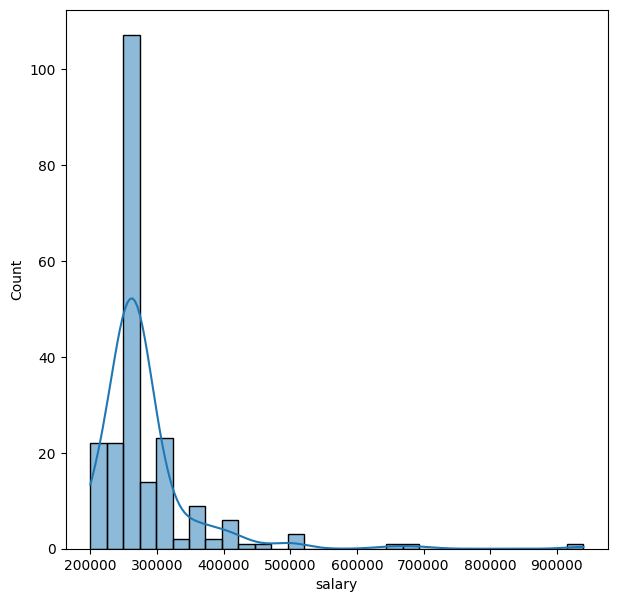

In [16]:
# analyse the distribution of data in the salary
# ax → the plotting area (axes)
fig, ax = plt.subplots(figsize=(7, 7))
sns.histplot(dataset['salary'], kde=True, ax=ax)
plt.show()

# histplot() → replaces distplot | histplot = histogram plot

# A histogram:
# Divides data into bins (ranges)
# Counts how many values fall inside each range
# Shows frequency distribution

# KDE = Kernel Density Estimation
# kde=True → adds the smooth density curve (like old distplot)
# if we remove it we get only bars

# ax=ax → plots on your defined axis

Replace the missing values with Median value

In [17]:
dataset['salary'].fillna(dataset['salary'].median(),inplace=True)
# Mean → sensitive to extreme values (outliers)
# Median → robust to outliers

# Salaries:
# Mean = heavily pulled upward
# Median = stays near typical value

# If one CEO earns 1 crore, mean becomes useless.
# Missing salaries are likely around the "typical" value and distribution is not symmetric.

/tmp/ipykernel_31774/2857827090.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['salary'].fillna(dataset['salary'].median(),inplace=True)


In [18]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [ ]:
dataset['salary'].skew()
# If skewness > 1 → strongly skewed → median safer.

np.float64(4.440110614947307)

In [21]:
# filling missing values with Mean value:
# dataset['salary'].fillna(dataset['salary'].mean(),inplace=True)

In [ ]:
# filling missing values with mode value:
# dataset['salary'].fillna(dataset['salary'].mode(),inplace=True)

# Mode only makes sense when:
# Data is categorical
# OR discrete with few repeated values
# Salary is continuous numeric.


Dropping Method

In [23]:
salary_dataset = pd.read_excel('../../Data/Placement_Dataset.xlsx')

In [24]:
salary_dataset.shape

(215, 15)

In [25]:
salary_dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [27]:
# drop the missing values   
salary_dataset = salary_dataset.dropna(how='any')


# how='any' ---> Drop the row if it contains at least one NaN value.
# how='all' ---> Drop row only if all columns are NaN

In [28]:
salary_dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [29]:
salary_dataset.shape

(148, 15)